# **SleepDisorderRiskPrediction - Avance 3/4**
Gabriela Chimali Nava Ramírez

19/04/2026

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import json

from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Cargar conjuntos de datos

In [15]:
PROJECT_PATH = '/content/drive/MyDrive/8vo/IA'
df_train = pd.read_csv(PROJECT_PATH + '/train_set.csv')
df_val = pd.read_csv(PROJECT_PATH + '/val_set.csv')
df_test = pd.read_csv(PROJECT_PATH + '/test_set.csv')

X_train = df_train.drop(columns=['sleep_disorder_risk']).values
y_train = df_train['sleep_disorder_risk'].values

X_val = df_val.drop(columns=['sleep_disorder_risk']).values
y_val = df_val['sleep_disorder_risk'].values

X_test = df_test.drop(columns=['sleep_disorder_risk']).values
y_test = df_test['sleep_disorder_risk'].values

## 2. Construcción del modelo
### 2.1. Declaración del modelo

In [16]:
INPUT_DIM = 57
NUM_CLASSES = 4

model = Sequential([
    # Capa Entrada
    Dense(128, activation='relu', input_shape=(INPUT_DIM,)),
    BatchNormalization(),
    Dropout(0.3),
    # Capa Oculta 2
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation="softmax") # Multiclase
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         7,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,452 (64.27 KB)

 Trainable params: 16,196 (63.27 KB)

 Non-trainable params: 256 (1.00 KB)

### 2.2. Compilación del modelo

In [18]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
dict_weights = dict(enumerate(weights))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose = 1
)

## 3. Entrenamiento

In [19]:
history = model.fit(
    X_train, y_train,
    class_weight=dict_weights,
    epochs=100,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=early_stop,
    verbose=1
)

Epoch 1/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.7153 - loss: 0.7397 - val_accuracy: 0.8031 - val_loss: 0.4451
Epoch 2/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7790 - loss: 0.5950 - val_accuracy: 0.8286 - val_loss: 0.3863
Epoch 3/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7953 - loss: 0.5591 - val_accuracy: 0.8223 - val_loss: 0.3897
Epoch 4/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8005 - loss: 0.5398 - val_accuracy: 0.8231 - val_loss: 0.3779
Epoch 5/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8037 - loss: 0.5256 - val_accuracy: 0.8253 - val_loss: 0.3813
Epoch 6/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8101 - loss: 0.5101 - val_accuracy: 0.8383 - val_loss: 0.3521
Epoch 7/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8121 - loss: 0.4999 - val_accuracy: 0.8291 - val_loss: 0.3711
Epoch 8/100
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8159 - loss: 

## 4. Métricas de entrenamiento

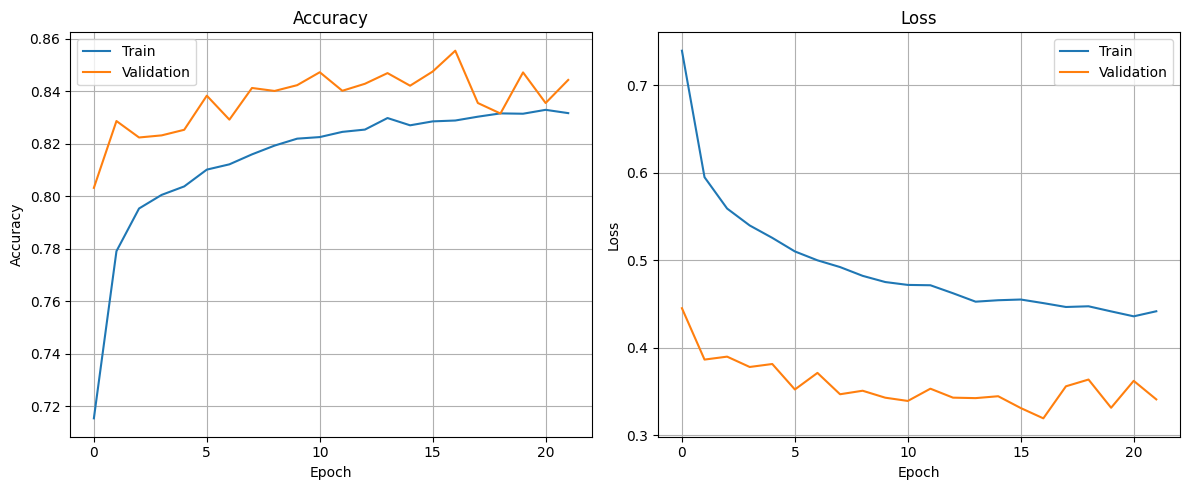

In [20]:
hist_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
hist_df[['accuracy', 'val_accuracy']].plot(ax=plt.gca())
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
hist_df[['loss', 'val_loss']].plot(ax=plt.gca())
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Evaluación del modelo (TEST)
### 5.1. Evaluación y predicciones general

In [37]:
class_names = ['Healthy', 'Mild', 'Moderate', 'Severe']

# Evaluación
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predicciones
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8545 - loss: 0.3160

Test Loss: 0.3160
Test Accuracy: 0.8545
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


### 5.2. Obtener métricas por clase

In [38]:
# Reporte
report = classification_report(y_true, y_pred, target_names=class_names,
                               zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose().loc[class_names]

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
total_samples = np.sum(cm)
accuracy_per_class = []

for i in range(len(class_names)):
    tp = cm[i, i]
    fp = np.sum(cm[:, i]) - tp
    fn = np.sum(cm[i, :]) - tp
    tn = total_samples - (tp + fp + fn)
    accuracy_per_class.append((tp + tn) / total_samples)

# Reorganizar
report_df['accuracy'] = accuracy_per_class
metrics = ['precision', 'recall', 'f1-score', 'accuracy']
report_df = report_df[metrics]

### 5.3. Graficar métricas por clase

<Figure size 1200x800 with 0 Axes>

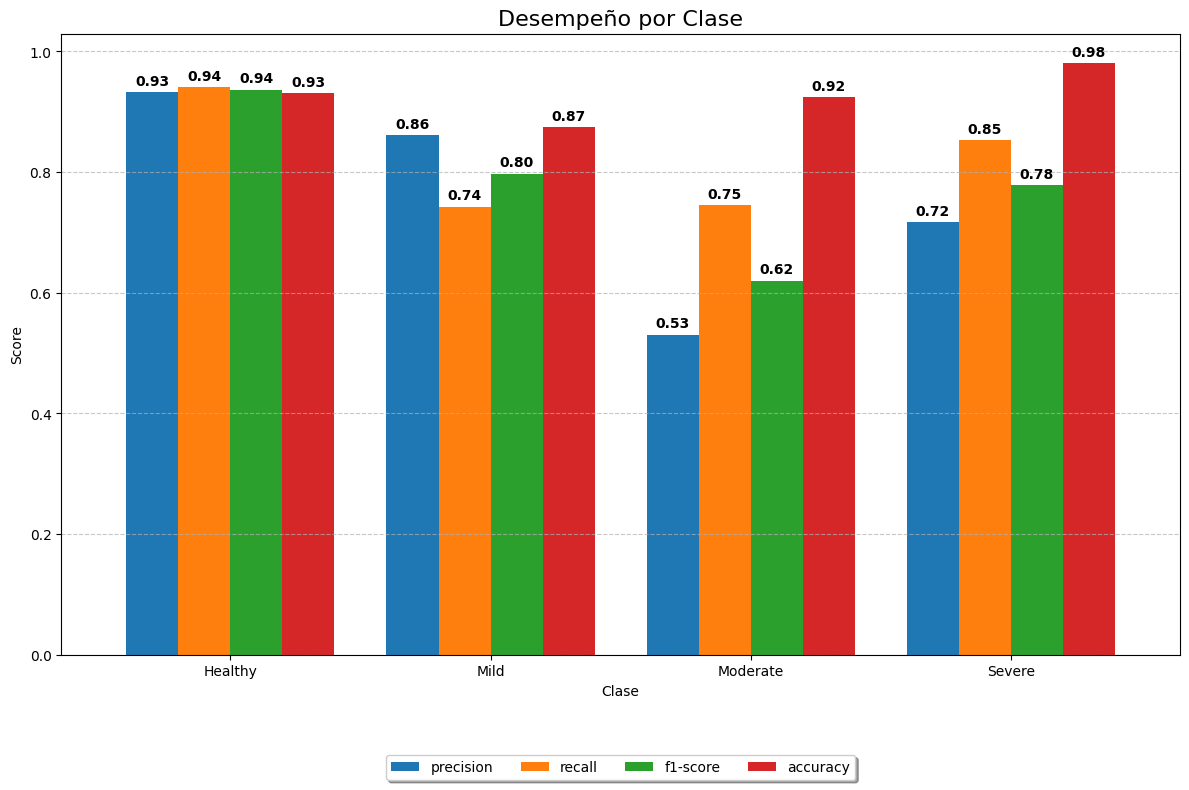

In [44]:
plt.figure(figsize=(12,8))
ax = report_df.plot(kind='bar', figsize=(12, 8), width=0.8)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontweight='bold')
plt.title("Desempeño por Clase", fontsize=16)
plt.xlabel("Clase")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
           ncol=4, frameon=True, shadow=True)
plt.tight_layout()
plt.show()

### 5.4. Matriz de confusión

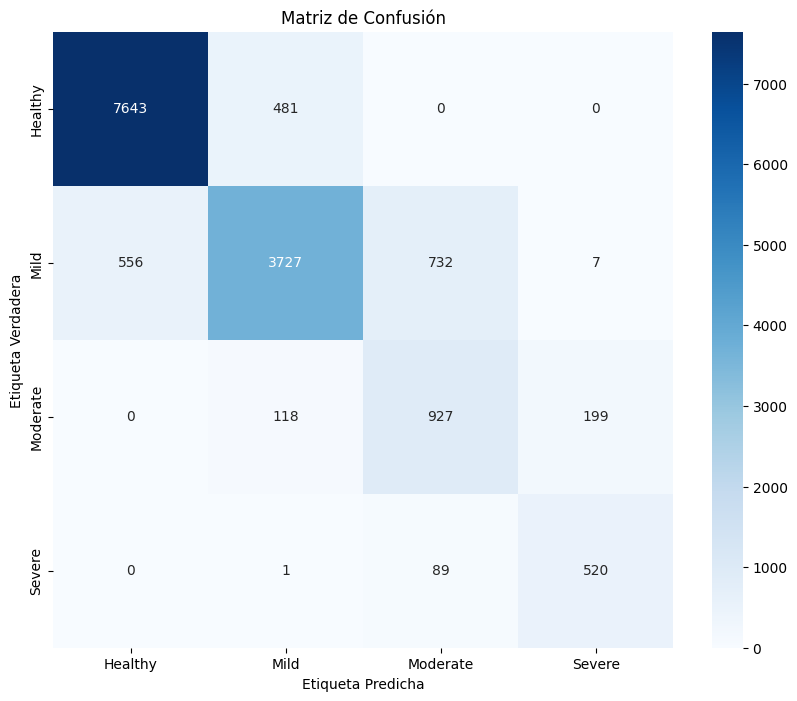

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de Confusión")
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.show()

## 6. Guardar modelo

In [ ]:
model.save(PROJECT_PATH + "/classifier_model.keras")

with open(PROJECT_PATH + '/history.json', 'w') as f:
    json.dump(history.history, f)